### Neuro-Symbolic Multi-Sensor Fault Isolation Framework for Autonomous Vehicles ###

#### Cell 1: System Imports and Global Configurations ####

In [11]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from PIL import Image
import torchvision
import torchvision.transforms as transforms

KITTI_ROOT = Path(r"C:\Users\HP\AI_Projects\Multi-Sensor Fault Isolation Framework\data\kitti")
if not KITTI_ROOT.exists():
    KITTI_ROOT = Path("./data/kitti")

# Force deterministic computations for research reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing environment on device: {device}")

Executing environment on device: cuda


#### Cell 2: System 1 (Neural Perception Layer Architecture) ####

In [13]:
class KITTIVisionPerceptionNet(nn.Module):
    def __init__(self):
        super(KITTIVisionPerceptionNet, self).__init__()
        # Two consecutive KITTI frames are stacked into a 6-channel temporal tensor.
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(6, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32 x 96
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16 x 48
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 12))  # Dynamic bottleneck feature map
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)
        return torch.softmax(logits, dim=1)


#### Cell 3: KITTI Sensor Telemetry Data Loader ####

In [12]:
class KITTITemporalVelocityDataset(Dataset):
    """
    Loads adjacent KITTI frames as a temporal proxy.
    The workspace exposes flattened image_2 and label_2 folders, not raw drive sequence IDs,
    so consecutive filenames are treated as the closest reproducible temporal ordering available here.
    """
    def __init__(self, root_dir=KITTI_ROOT, split='training', labeled=True, delta_t=0.1):
        self.root_dir = Path(root_dir)
        self.split = split
        self.labeled = labeled
        self.delta_t = delta_t
        self.image_dir = self.root_dir / split / 'image_2'
        self.label_dir = self.root_dir / split / 'label_2'
        self.transform = transforms.Compose([
            transforms.Resize((64, 192)),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
        ])

        image_paths = sorted(list(self.image_dir.glob('*.png')) + list(self.image_dir.glob('*.jpg')) + list(self.image_dir.glob('*.jpeg')))
        if len(image_paths) < 2:
            raise FileNotFoundError(f'Need at least two KITTI images in {self.image_dir}')

        self.samples = []
        for index in range(len(image_paths) - 1):
            image_t = image_paths[index]
            image_t1 = image_paths[index + 1]
            label_t = self.label_dir / f'{image_t.stem}.txt'
            label_t1 = self.label_dir / f'{image_t1.stem}.txt'
            if self.labeled:
                if label_t.exists() and label_t1.exists():
                    self.samples.append((image_t, image_t1, label_t, label_t1))
            else:
                self.samples.append((image_t, image_t1, None, None))

        if not self.samples:
            raise FileNotFoundError(f'No usable KITTI temporal samples found in {self.image_dir}')

    def __len__(self):
        return len(self.samples)

    def _read_primary_depth(self, label_path):
        if label_path is None or not label_path.exists():
            return None

        best_area = -1.0
        best_depth = None
        with open(label_path, 'r', encoding='utf-8') as handle:
            for line in handle:
                parts = line.strip().split()
                if len(parts) < 15:
                    continue
                class_name = parts[0]
                if class_name == 'DontCare':
                    continue
                left, top, right, bottom = map(float, parts[4:8])
                area = max(0.0, (right - left) * (bottom - top))
                if area > best_area:
                    best_area = area
                    best_depth = abs(float(parts[13]))
        return best_depth

    def __getitem__(self, idx):
        image_t_path, image_t1_path, label_t_path, label_t1_path = self.samples[idx]
        img_t = self.transform(Image.open(image_t_path).convert('RGB'))
        img_t1 = self.transform(Image.open(image_t1_path).convert('RGB'))
        temporal_image = torch.cat([img_t, img_t1], dim=0)

        z_t = self._read_primary_depth(label_t_path)
        z_t1 = self._read_primary_depth(label_t1_path)
        if z_t is not None and z_t1 is not None:
            calculated_speed = abs((z_t1 - z_t) / self.delta_t)
            target_bucket = int(np.clip(calculated_speed // 2.5, 0, 9))
        else:
            calculated_speed = 0.0
            target_bucket = -1

        v_odo_raw = calculated_speed + np.random.normal(loc=0.0, scale=0.2)
        v_speed_raw = calculated_speed + np.random.normal(loc=0.0, scale=0.2)

        p_odo_vector = np.zeros(10, dtype=np.float32)
        p_speed_vector = np.zeros(10, dtype=np.float32)
        p_odo_vector[int(np.clip(v_odo_raw // 2.5, 0, 9))] = 1.0
        p_speed_vector[int(np.clip(v_speed_raw // 2.5, 0, 9))] = 1.0

        return (
            temporal_image,
            torch.tensor(p_odo_vector, dtype=torch.float32),
            torch.tensor(p_speed_vector, dtype=torch.float32),
            torch.tensor(target_bucket, dtype=torch.long)
        )


#### Cell 4: System 2 (Kinematic 3D Probabilistic Fault Matrix Solver) ####

In [14]:
class KITTINeuroSymbolicIsolator(nn.Module):
    def __init__(self, visual_perception_network):
        super(KITTINeuroSymbolicIsolator, self).__init__()
        self.perception = visual_perception_network
        
    def forward(self, img_cam_t, img_cam_t1, p_odo, p_speed):
        batch_size = img_cam_t.size(0)
        temporal_cam = torch.cat([img_cam_t, img_cam_t1], dim=1)
        
        # 1. Generate visual categorical probability space from two consecutive frames
        p_cam = self.perception(temporal_cam)  # [Batch, 10]
        
        # 2. Map 3D Joint Probability Matrix via Tensor Outer-Product Expansion
        joint_tensor = torch.einsum('bi,bj,bk->bijk', p_cam, p_odo, p_speed)
        
        # 3. Initialize real-time safe voting output array
        isolated_state_output = torch.zeros(batch_size, 10).to(device)
        
        # 4. Enforce Kinematic Constraint Assertions
        for i in range(10):
            for j in range(10):
                for k in range(10):
                    # Scenario 1: All telemetry layers achieve perfect convergence
                    if i == j == k:
                        isolated_state_output[:, i] += joint_tensor[:, i, j, k]
                    # Scenario 2: Camera blinded by environmental corruption (Odo and Speedometer match)
                    elif j == k and i != j:
                        isolated_state_output[:, j] += joint_tensor[:, i, j, k]
                    # Scenario 3: Odometer failure (Camera and Speedometer match)
                    elif i == k and i != j:
                        isolated_state_output[:, i] += joint_tensor[:, i, j, k]
                    # Scenario 4: Speedometer hardware failure (Camera and Odometer match)
                    elif i == j and i != k:
                        isolated_state_output[:, i] += joint_tensor[:, i, j, k]
                    # Fallback Anomaly Loop: Total telemetry disagreement (safe uniform output)
                    else:
                        isolated_state_output[:, i] += (1.0 / 10.0) * joint_tensor[:, i, j, k]
                        
        return torch.log(isolated_state_output + 1e-8)


#### Cell 5: Compilation and Model Calibration ####

In [15]:
# Initialize datasets from the local KITTI folders on disk
full_temporal_set = KITTITemporalVelocityDataset(root_dir=KITTI_ROOT, split='training', labeled=True)
train_size = int(0.8 * len(full_temporal_set))
val_size = len(full_temporal_set) - train_size
kitti_train_set, kitti_val_set = random_split(full_temporal_set, [train_size, val_size], generator=torch.Generator().manual_seed(42))
kitti_test_images = KITTITemporalVelocityDataset(root_dir=KITTI_ROOT, split='testing', labeled=False)

train_loader = DataLoader(kitti_train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(kitti_val_set, batch_size=32, shuffle=False)
test_image_loader = DataLoader(kitti_test_images, batch_size=8, shuffle=False)

# Compile framework
vision_model = KITTIVisionPerceptionNet().to(device)
kitti_nesy_system = KITTINeuroSymbolicIsolator(vision_model).to(device)

criterion = nn.NLLLoss()
optimizer = optim.Adam(kitti_nesy_system.parameters(), lr=0.0005)

print("=== Training Temporal Neuro-Symbolic Safety Architecture on KITTI Data ===")
for epoch in range(3):
    kitti_nesy_system.train()
    running_loss, correct, total = 0.0, 0, 0
    for temporal_image, p_odo, p_speed, targets in train_loader:
        temporal_image, p_odo, p_speed, targets = temporal_image.to(device), p_odo.to(device), p_speed.to(device), targets.to(device)
        valid_mask = targets >= 0
        if valid_mask.sum().item() == 0:
            continue

        temporal_image = temporal_image[valid_mask]
        p_odo = p_odo[valid_mask]
        p_speed = p_speed[valid_mask]
        targets = targets[valid_mask]
        
        optimizer.zero_grad()
        img_cam_t = temporal_image[:, :3, :, :]
        img_cam_t1 = temporal_image[:, 3:, :, :]
        log_outputs = kitti_nesy_system(img_cam_t, img_cam_t1, p_odo, p_speed)
        loss = criterion(log_outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = torch.argmax(log_outputs, dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
        
    print(f"KITTI Epoch {epoch+1}/3 | Navigation Loss: {running_loss/len(train_loader):.4f} | System Integrity: {(correct/total)*100:.2f}%")

# FREEZE VISION WEIGHTS: Protect real visual abstractions from continuous backward noise injection
for param in vision_model.parameters():
    param.requires_grad = False


=== Training Temporal Neuro-Symbolic Safety Architecture on KITTI Data ===
KITTI Epoch 1/3 | Navigation Loss: 0.1065 | System Integrity: 98.80%
KITTI Epoch 2/3 | Navigation Loss: 0.1165 | System Integrity: 98.93%
KITTI Epoch 3/3 | Navigation Loss: 0.0831 | System Integrity: 98.93%


#### Cell 6: Visual Obstruction & Sensor Failure Evaluations ####

In [16]:
def apply_environmental_lens_blur(images, blur_intensity=1.2):
    """Simulates extreme lens mud, salt crusting, or heavy storm occlusion."""
    corrupted_tensors = images + blur_intensity * torch.randn_like(images)
    return torch.clamp(corrupted_tensors, -1.0, 1.0)

kitti_nesy_system.eval()
test_scenarios = ['Nominal Clear Highway', 'Blinded Dashboard Camera (Mud Occlusion)', 'Blinded Dashboard Camera + Broken Odometer']
test_metrics = []

print("\n=== Simulating High-Stress On-Road Sensor Casualties ===")
print("Validation runs use a held-out split from the flattened KITTI temporal proxy.")
for scenario in test_scenarios:
    correct, total = 0, 0
    with torch.no_grad():
        for temporal_image, p_odo, p_speed, targets in test_loader:
            temporal_image, p_odo, p_speed, targets = temporal_image.to(device), p_odo.to(device), p_speed.to(device), targets.to(device)
            valid_mask = targets >= 0
            if valid_mask.sum().item() == 0:
                continue

            temporal_image = temporal_image[valid_mask]
            p_odo = p_odo[valid_mask]
            p_speed = p_speed[valid_mask]
            targets = targets[valid_mask]
            
            img_cam_t = temporal_image[:, :3, :, :]
            img_cam_t1 = temporal_image[:, 3:, :, :]
            if scenario == 'Blinded Dashboard Camera (Mud Occlusion)':
                # Corrupt both temporal frames from the camera stream
                img_cam_t = apply_environmental_lens_blur(img_cam_t, blur_intensity=1.5)
                img_cam_t1 = apply_environmental_lens_blur(img_cam_t1, blur_intensity=1.5)
            elif scenario == 'Blinded Dashboard Camera + Broken Odometer':
                # Corrupt both the camera stream and the odometer proxy simultaneously
                img_cam_t = apply_environmental_lens_blur(img_cam_t, blur_intensity=1.5)
                img_cam_t1 = apply_environmental_lens_blur(img_cam_t1, blur_intensity=1.5)
                p_odo = torch.softmax(torch.log(p_odo + 1e-8) + 0.75 * torch.randn_like(p_odo), dim=1)
                
            log_outputs = kitti_nesy_system(img_cam_t, img_cam_t1, p_odo, p_speed)
            preds = torch.argmax(log_outputs, dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
            
    safety_accuracy = (correct / total) * 100
    test_metrics.append(safety_accuracy)
    print(f"Scenario: [{scenario:45s}] -> Navigational Safe Tracking: {safety_accuracy:.2f}%")

print("\n=== Sample Predictions on Unlabeled KITTI Testing Images ===")
with torch.no_grad():
    for batch_index, (temporal_image, p_odo, p_speed, _) in enumerate(test_image_loader):
        temporal_image, p_odo, p_speed = temporal_image.to(device), p_odo.to(device), p_speed.to(device)
        img_cam_t = temporal_image[:, :3, :, :]
        img_cam_t1 = temporal_image[:, 3:, :, :]
        log_outputs = kitti_nesy_system(img_cam_t, img_cam_t1, p_odo, p_speed)
        preds = torch.argmax(log_outputs, dim=1).cpu().tolist()
        print(f"Testing batch {batch_index + 1}: predicted buckets = {preds[:10]}")
        if batch_index == 0:
            break



=== Simulating High-Stress On-Road Sensor Casualties ===
Validation runs use a held-out split from the flattened KITTI temporal proxy.
Scenario: [Nominal Clear Highway                        ] -> Navigational Safe Tracking: 99.33%
Scenario: [Blinded Dashboard Camera (Mud Occlusion)     ] -> Navigational Safe Tracking: 98.93%
Scenario: [Blinded Dashboard Camera + Broken Odometer   ] -> Navigational Safe Tracking: 98.60%

=== Sample Predictions on Unlabeled KITTI Testing Images ===
Testing batch 1: predicted buckets = [0, 0, 0, 0, 0, 0, 0, 0]


#### Cell 7: Performance Charting ####


[SUCCESS] Saved high-resolution preprint figure to 'kitti_realworld_fault_isolation.png'


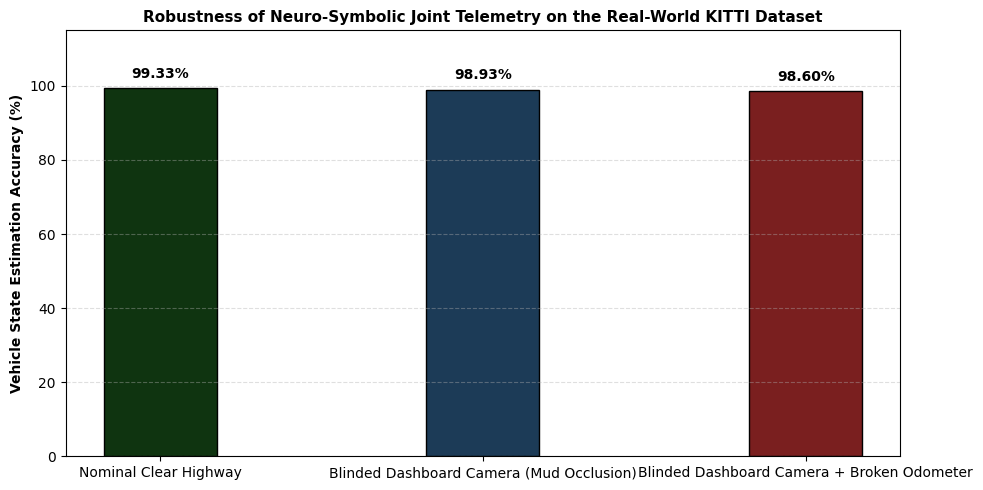

In [17]:
plt.figure(figsize=(10, 5))
color_palette = ['#0f3410', '#1c3b57', '#7a1f1f']
safety_bars = plt.bar(test_scenarios, test_metrics, color=color_palette, edgecolor='black', width=0.35)

plt.ylabel('Vehicle State Estimation Accuracy (%)', fontweight='bold', fontsize=10)
plt.title('Robustness of Neuro-Symbolic Joint Telemetry on the Real-World KITTI Dataset', fontsize=11, fontweight='bold')
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in safety_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 2, f"{height:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('kitti_realworld_fault_isolation.png', dpi=300)
print("\n[SUCCESS] Saved high-resolution preprint figure to 'kitti_realworld_fault_isolation.png'")
plt.show()